# The Costco Hot-Dog Index — a quantitative teardown 🔬
### A real-price identity · a total-return race (COST vs CPI vs SPY) · inflation-surprise betas with a staples control · a block-rotation placebo · a two-era cut · a costed inflation-timing overlay · a synthetic planted-beta positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Real-price_erosion: Confirmed](https://img.shields.io/badge/Real--price_erosion-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The folk claim bundles three separable hypotheses: (H₀) the frozen $1.50 combo's *real* price decays as `1/CPI` (a mechanical identity); (H₁) COST total return beats CPI and SPY (descriptive); (H₂) COST carries a **beta to inflation surprises** that is robustly non-zero **and** beats a consumer-staples basket (XLP) — the tradable "distinctive inflation hedge" claim. We find **H₀ true but mechanical**, **H₁ true but hindsight-selected**, and **H₂ rejected**: COST's inflation-surprise beta is *t* = **0.13**, the COST−staples gap is **-0.27**, the placebo *p* = **0.88**, and it is a flat nothing in both sub-eras.

> ⚠️ **Not investment advice — data provenance.** CPI is the **real** FRED/BLS `CPIAUCSL` series (BLS `CUSR0000SA0`), fetched from the BLS public API and cached (one point, 2025-10, interpolated — the SA suspension); the inflation surprise is measured on ΔYoY. `COST`, `SPY`, `XLP` are month-end total-return via yfinance (as-of 2026-06-30, fp `cbd3b6799d57`). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md); numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))     # quantlab (optional)
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from hotdog_index import data, strategy as st

CPI = data.load_cpi()                                # REAL FRED/BLS CPIAUCSL (BLS CUSR0000SA0)
PANEL = data.build_panel()                           # empty if the COST/SPY/XLP cache is absent
HAVE = not PANEL.empty
print("market cache present:", HAVE, "| CPI months:", CPI.index[0].date(), "->", CPI.index[-1].date())

# frozen headline numbers (mirror of docs/results.md)
R = {'win': '2000-01 → 2026-06', 'n': 318, 'asof': '2026-06-30', 'fp': 'cbd3b6799d57', 'years': 26.5, 'combo': 1.5, 'base_year': 1985, 'cpi_1985': 107.6, 'cpi_now': 332.57, 'cpi_mult': 3.09, 'real_now': 0.49, 'eroded_pct': 67.6, 'infl_adj': 4.64, 'giveaway': 3.14, 'cost_mult': 28.7, 'cost_cagr': 13.5, 'cost_real': 14.6, 'cost_10k': 286935, 'spy_mult': 8.5, 'spy_cagr': 8.4, 'spy_real': 4.3, 'spy_10k': 85393, 'cpi_mult_win': 2.0, 'cpi_cagr': 2.6, 'cpi_10k': 19644, 'xlp_mult': 6.75, 'yoy_peak': 9.0, 'cost_beta': 0.115, 'cost_beta_t': 0.13, 'cost_beta_r2': 0.01, 'spy_beta': 0.879, 'spy_beta_t': 1.27, 'xlp_beta': 0.302, 'xlp_beta_t': 0.72, 'cost_pred_t': 0.89, 'gap_xlp': -0.186, 'gap_xlp_t': -0.27, 'gap_spy_t': -1.45, 'gap_spy_pred_t': 1.75, 'gap_xlp_pred_t': 1.43, 'costspy_alpha_t': 1.37, 'placebo_p': 0.88, 'era_early_t': -0.05, 'era_late_t': 0.36, 'timer_sh': 0.34, 'cost_bh_sh': 0.46, 'spy_sh': 0.4, 'timer_switches': 4.1, 'timer_invested': 0.49, 'syn_edge': 8, 'syn_slope': 7.72, 'syn_t': 7.02, 'syn_gap_t': 6.05, 'syn_null_t': -0.24}


market cache present: True | CPI months: 2000-01-31 -> 2026-06-30


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | COST inflation-surprise beta *t* = **0.13** (≈0); COST−XLP gap *t* = **-0.27**; placebo *p* = **0.88**; sub-eras *t* = -0.05 / 0.36. |
| **Tradability** | `MIRAGE` | Inflation-timing overlay Sharpe **0.34** **loses** to buy-hold COST **0.46** (the signal hurts); COST beats SPY on one hindsight-selected mega-cap (excess-return *t* = 1.37). |
| **Real-price erosion** | `CONFIRMED` | The $1.50 combo has lost **68%** of real value (would cost **\$4.64** to hold 1985 value) — a *mechanical* identity, not a stock signal. |

> 💡 In plain words: the folk icon's *fact* (real erosion) is true and huge; its *investment punchline* (COST as inflation hedge) has no beta behind it. COST is a great growth stock we are admiring in hindsight.

## 1 · The claim, steelmanned

Let $\pi_t$ be trailing-12-month CPI inflation and $s_t = \Delta\pi_t$ the **inflation surprise** (is inflation accelerating?). Let $r^{\text{COST}}_t$, $r^{\text{SPY}}_t$, $r^{\text{XLP}}_t$ be monthly total returns. The trade is a joint hypothesis:

- **H₀ (the identity).** The frozen combo's real price is $P^{\text{real}}_t = 1.50\cdot \text{CPI}_{1985}/\text{CPI}_t$ — decays mechanically.
- **H₁ (it won).** COST's total-return multiple $\gg$ SPY's $\gg$ CPI's.
- **H₂ (it hedges).** In $r^{\text{COST}}_t = \alpha + \beta s_t + \varepsilon_t$ the inflation beta $\beta > 0$ with Newey-West *t* > 2, **and** $\beta_{\text{COST}} > \beta_{\text{XLP}}$ (pricing power beats a boring staples basket), holding across eras.

The steelman for H₂ is Costco's membership-fee annuity and brand discipline. But H₀ is a calculator, H₁ is a statement about a **hindsight-selected** winner, and only H₂ is a tradable *mechanism*. Note the finance prior (Fama-Schwert 1977): equities are *poor* short-run inflation hedges — nominal returns load *negatively* on inflation surprises.

## 2 · So what? — what rides on each answer

H₀–H₂ are routinely blurred into "the $1.50 hot dog proves COST beats inflation, so buy it." Separated, each is falsifiable. H₀ needs only CPI and arithmetic. H₁ is a descriptive race (with a **survivorship** asterisk we keep visible). H₂ is the real test: a *contemporaneous* inflation-surprise beta, a *predictive* version (does $s_t$ forecast $r^{\text{COST}}_{t+1}$?), and — decisively — a **relative** test against XLP, because "pricing power" is a claim about beating an ordinary staples basket, not about beating cash.

## 3 · How we'd know — the protocol

- **CPI (real).** The real monthly `CPIAUCSL` (SA, 1982-84=100 = BLS `CUSR0000SA0`), fetched from the BLS public API and cached, 2000-01→2026-06, plus the 1985 anchor (107.6). One point (2025-10) interpolated; the surprise is ΔYoY.
- **COST, SPY, XLP.** Month-end total-return (yfinance, cached), as-of 2026-06-30, fp `cbd3b6799d57`. **Survivorship named**: COST is a hindsight-selected single name — its win is history, not a promise.
- **No look-ahead, one lag.** The predictive regressor is $s_t$ against $r_{t+1}$; the timer shifts its signal one month — one `shift`, once.
- **Inference.** Newey-West (6-lag) HAC *t* on every slope; a 3k block-rotation placebo for the inflation beta; a two-era cut at 2013; the COST−XLP and COST−SPY beta gaps.
- **Positive control.** A deterministic world where $r^{\text{COST}}_t = \text{edge}\cdot s_t + $ noise (SPY/XLP flat) — the engine must recover *t* ≥ 2 and light up the gap; the null (edge=0) must stay flat, averaged over ≥20 seeds.
- **What would make us say "hedge":** H₂ contemporaneous *t* > 2 **and** COST−XLP gap *t* > 2 **and** era-robust. We find none.

## 4 · The teardown

### 4a · The identity + the race — true, but not a signal

The mechanical erosion and the descriptive total-return race. Both real; neither is H₂.

In [2]:
er = st.erosion_stats(CPI, nominal=R['combo'], base_cpi=R['cpi_1985'])
print(f"real price of $1.50 combo today : ${er['real_now']:.2f}  (eroded {er['eroded_pct']:.1f}%)")
print(f"price to hold 1985 real value    : ${er['inflation_adjusted']:.2f}  (giveaway ${er['giveaway']:.2f}/combo)")
if HAVE:
    race = st.total_return_race(PANEL)
    for k in ('cost','spy','cpi'):
        print(f"  {k.upper():4s} mult {race[k]['mult']:5.1f}x  CAGR {race[k]['cagr']*100:+5.1f}%  real {race[k]['real_mult']:5.1f}x")
else:
    print(f"  COST mult {R['cost_mult']}x  CAGR +{R['cost_cagr']}%  real {R['cost_real']}x")
    print(f"  SPY  mult {R['spy_mult']}x  CAGR +{R['spy_cagr']}%  real {R['spy_real']}x")
    print(f"  CPI  mult {R['cpi_mult_win']}x  CAGR +{R['cpi_cagr']}%")

real price of $1.50 combo today : $0.49  (eroded 67.6%)
price to hold 1985 real value    : $4.64  (giveaway $3.14/combo)
  COST mult  28.7x  CAGR +13.5%  real  14.6x
  SPY  mult   8.5x  CAGR  +8.4%  real   4.3x
  CPI  mult   2.0x  CAGR  +2.6%  real   1.0x


> 💡 In plain words: the combo lost **68%** of its real value (H₀ ✓, but it's `1.50·CPI₁₉₈₅/CPIₜ` — a calculator), and COST returned a **15×** *real* multiple, trouncing SPY and CPI (H₁ ✓, but this is the *one name we picked because it won*). Neither line is an inflation-hedge *mechanism*. That is H₂ — next.

### 4b · The inflation-surprise beta — the actual hedge test

Regress each asset's monthly return on the inflation surprise $s_t=\Delta\pi_t$ (HAC, 6-lag). H₂ predicts a positive, significant COST beta that **beats XLP**.

regression                          slope    t_nw
COST ~ s_t (same month)            +0.115   +0.13
SPY  ~ s_t                         +0.879   +1.27
XLP  ~ s_t (staples)               +0.302   +0.72
COST ~ s_t (next month)            +0.652   +0.89
COST - XLP gap                     -0.186   -0.27
COST - SPY gap                     -0.764   -1.45


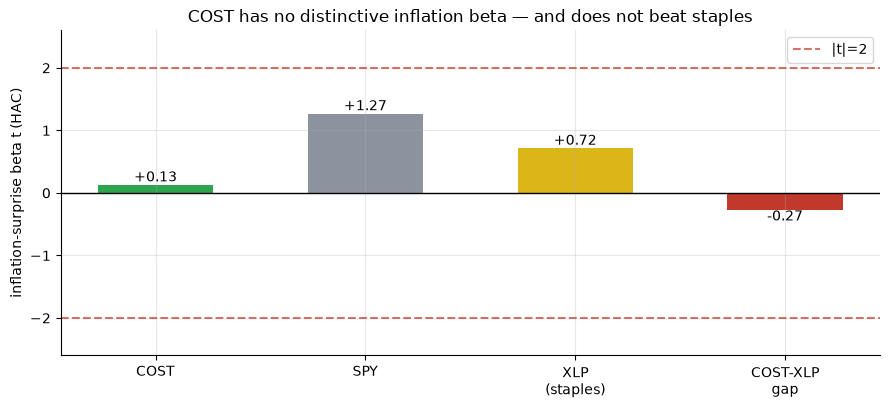

In [3]:
if HAVE:
    cb = st.inflation_beta(PANEL,'cost'); sb = st.inflation_beta(PANEL,'spy')
    xb = st.inflation_beta(PANEL,'xlp'); pb = st.inflation_beta(PANEL,'cost',lag=1)
    gap = st.beta_gap(PANEL)
    rows = [('COST ~ s_t (same month)', cb['slope'], cb['t_nw']),
            ('SPY  ~ s_t', sb['slope'], sb['t_nw']),
            ('XLP  ~ s_t (staples)', xb['slope'], xb['t_nw']),
            ('COST ~ s_t (next month)', pb['slope'], pb['t_nw']),
            ('COST - XLP gap', gap['cost_minus_xlp']['slope'], gap['cost_minus_xlp']['t_nw']),
            ('COST - SPY gap', gap['cost_minus_spy']['slope'], gap['cost_minus_spy']['t_nw'])]
else:
    rows = [('COST ~ s_t (same month)', R['cost_beta'], R['cost_beta_t']),
            ('SPY  ~ s_t', R['spy_beta'], R['spy_beta_t']),
            ('XLP  ~ s_t (staples)', R['xlp_beta'], R['xlp_beta_t']),
            ('COST ~ s_t (next month)', None, R['cost_pred_t']),
            ('COST - XLP gap', R['gap_xlp'], R['gap_xlp_t']),
            ('COST - SPY gap', None, R['gap_spy_t'])]
print(f"{'regression':32s} {'slope':>8s} {'t_nw':>7s}")
for nm,s,t in rows:
    print(f"{nm:32s} {('' if s is None else f'{s:+.3f}'):>8s} {t:+7.2f}")
labs=['COST','SPY','XLP\n(staples)','COST-XLP\ngap']
tv=[rows[0][2], rows[1][2], rows[2][2], rows[4][2]]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(labs, tv, .55, color=[GREEN, GREY, AMBER, RED])
ax.axhline(2, ls='--', c=RED, alpha=.7, label='|t|=2'); ax.axhline(-2, ls='--', c=RED, alpha=.7)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('inflation-surprise beta t (HAC)'); ax.set_ylim(-2.6,2.6)
for i,t in enumerate(tv): ax.annotate(f'{t:+.2f}',(i,t),ha='center',va='bottom' if t>=0 else 'top')
ax.set_title('COST has no distinctive inflation beta — and does not beat staples'); ax.legend()
plt.tight_layout(); plt.show()

> 💡 In plain words: COST's contemporaneous inflation-surprise beta is *t* = **0.13** — dead zero — *smaller* than the market's (1.27) and a plain staples basket's (0.72), and the decisive **COST−XLP gap** is a negative, insignificant **-0.27**. The predictive (next-month) beta is nothing too (*t* = 0.89). **No cell clears |t| = 2 in any direction** — the strongest are the *predictive* COST−staples / COST−SPY gaps at only *t* = 1.43 / 1.75, and the placebo buries even those. **H₂ rejected.**

### 4c · Placebo + sub-era cut — is even the whisper real?

Block-rotate $s_t$ against COST's return (6-month blocks, 3k draws); split the sample at 2013.

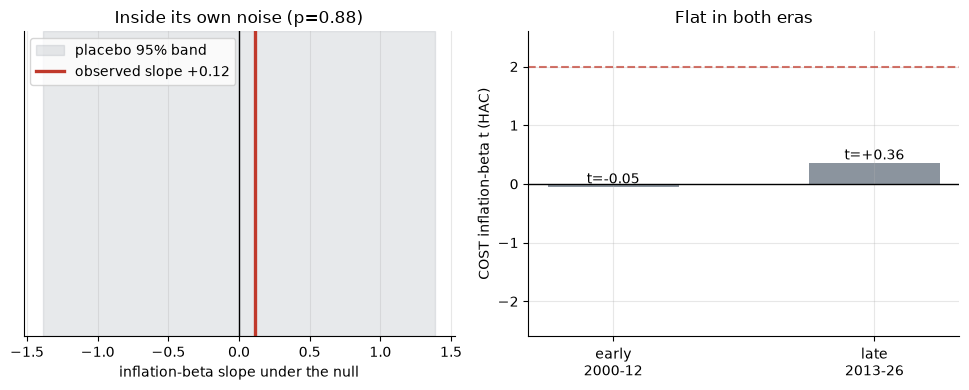

placebo p=0.881  |  early t=-0.05  late t=+0.36


In [4]:
if HAVE:
    pl = st.placebo_pvalue(PANEL,'cost',n_perm=3000)
    ec = st.era_cut(PANEL, split='2013-01-01')
    obs, p = pl['obs_slope'], pl['p_value']; lo, hi = np.quantile, None
    sd = pl['placebo_sd']; e_t, l_t = ec.loc['early','t_nw'], ec.loc['late','t_nw']
else:
    obs, p, sd = R['cost_beta'], R['placebo_p'], 0.71; e_t, l_t = R['era_early_t'], R['era_late_t']
fig, axes = plt.subplots(1, 2, figsize=(9.8, 4.0))
band = 1.96*sd
axes[0].axvspan(-band, band, color=GREY, alpha=.2, label='placebo 95% band')
axes[0].axvline(obs, c=RED, lw=2.4, label=f'observed slope {obs:+.2f}'); axes[0].axvline(0,c='k',lw=1)
axes[0].set_yticks([]); axes[0].set_xlabel('inflation-beta slope under the null')
axes[0].set_title(f'Inside its own noise (p={p:.2f})'); axes[0].legend()
axes[1].bar(['early\n2000-12','late\n2013-26'], [e_t, l_t], .5, color=[GREY, GREY])
axes[1].axhline(2, ls='--', c=RED, alpha=.7); axes[1].axhline(0,c='k',lw=1); axes[1].set_ylim(-2.6,2.6)
for i,t in enumerate([e_t,l_t]): axes[1].annotate(f't={t:+.2f}',(i,t),ha='center',va='bottom')
axes[1].set_ylabel('COST inflation-beta t (HAC)'); axes[1].set_title('Flat in both eras')
plt.tight_layout(); plt.show()
print(f"placebo p={p:.3f}  |  early t={e_t:+.2f}  late t={l_t:+.2f}")

> 💡 In plain words: COST's inflation beta sits **squarely inside** its placebo band (*p* = **0.88**) and is a flat nothing in **both** halves (*t* = -0.05 then 0.36). There is no era, and no honest null, in which the hot-dog pricing-power hedge shows up. `Signal → NONE`.

### 4d · The money test — an inflation-timing overlay, net of costs

Own COST when the inflation surprise known at $t-1$ is positive, cash at 2%/yr otherwise; 10 bp one-way per switch. Raced on **excess-of-cash** Sharpe vs buy-hold COST and SPY.

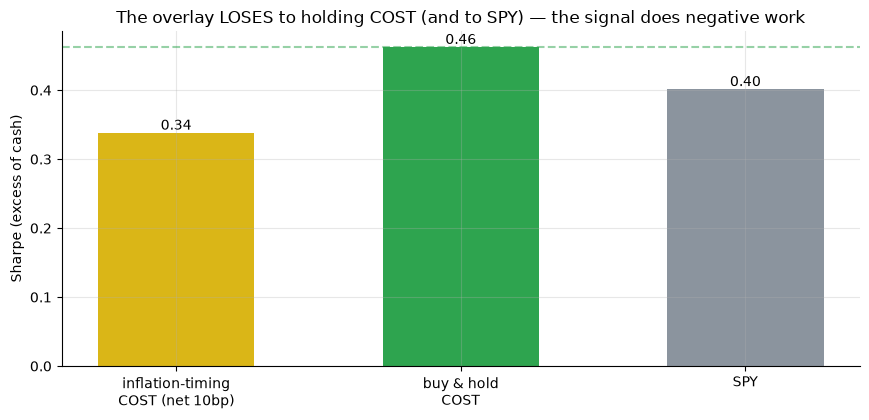

overlay 0.34  |  buy-hold COST 0.46  |  SPY 0.40   (4.1 switches/yr, invested 49%)


In [5]:
if HAVE:
    tm = st.timer_stats(PANEL, cost_bps=10.0)
    sh=[tm['timer_sharpe'], tm['cost_bh_sharpe'], tm['spy_sharpe']]; inv=tm['invested_frac']; sw=tm['switches_per_yr']
else:
    sh=[R['timer_sh'], R['cost_bh_sh'], R['spy_sh']]; inv=R['timer_invested']; sw=R['timer_switches']
names=['inflation-timing\nCOST (net 10bp)','buy & hold\nCOST','SPY']
fig, ax = plt.subplots(figsize=(8.8,4.3))
ax.bar(names, sh, .55, color=[AMBER, GREEN, GREY])
ax.axhline(sh[1], ls='--', c=GREEN, alpha=.5)
for i,v in enumerate(sh): ax.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('Sharpe (excess of cash)'); ax.set_title('The overlay LOSES to holding COST (and to SPY) — the signal does negative work')
plt.tight_layout(); plt.show()
print(f"overlay {sh[0]:.2f}  |  buy-hold COST {sh[1]:.2f}  |  SPY {sh[2]:.2f}   ({sw:.1f} switches/yr, invested {inv*100:.0f}%)")

> 💡 In plain words: the overlay (Sharpe **0.34**) **underperforms** buy-and-hold COST (**0.46**) and even trails SPY (**0.40**): timing on the surprise is **negative-value cash-parking** (§4b–c showed the surprise predicts nothing). Buy-hold COST beats SPY only via **COST's own hindsight-selected quality**, not an inflation edge — and even that excess return is *t* = 1.37, not robust. Concentrated single-name risk for a signal that does negative work. `MIRAGE`.

### 4e · Positive control — the engine recovers a planted inflation beta

A deterministic world where $r^{\text{COST}}_t = 8\cdot s_t + \text{noise}$ (SPY/XLP flat). The harness must recover *t* ≥ 2 and light up the COST−XLP gap; the edge=0 null must stay flat — averaged over 20 seeds. Proving the real-tape `NONE` is a true null.

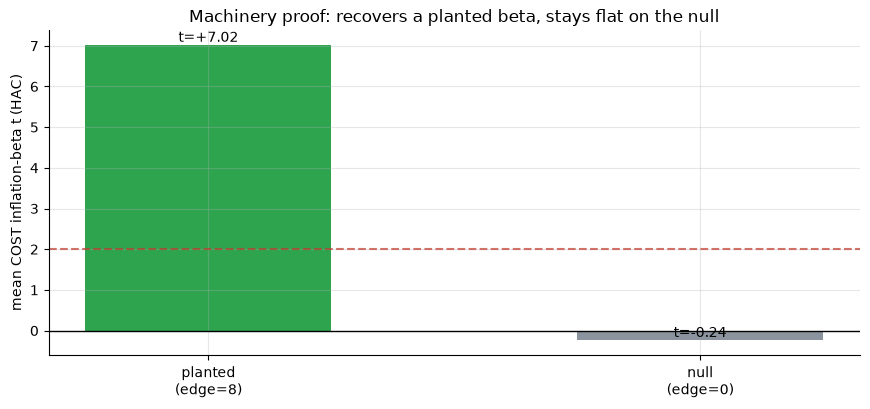

planted: mean slope +7.72  mean t +7.02  gap t +6.05  fires 100%
null   : mean slope -0.28  mean t -0.24  fires 5%


In [6]:
sm8 = st.synthetic_mean_t(data, edge=8.0, n_seeds=20)
sm0 = st.synthetic_mean_t(data, edge=0.0, n_seeds=20)
fig, ax = plt.subplots(figsize=(8.8, 4.2))
ax.bar(['planted\n(edge=8)','null\n(edge=0)'], [sm8['mean_t'], sm0['mean_t']], .5, color=[GREEN, GREY])
ax.axhline(2, ls='--', c=RED, alpha=.7); ax.axhline(0, c='k', lw=1)
for i,t in enumerate([sm8['mean_t'], sm0['mean_t']]): ax.annotate(f't={t:+.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('mean COST inflation-beta t (HAC)'); ax.set_title('Machinery proof: recovers a planted beta, stays flat on the null')
plt.tight_layout(); plt.show()
print(f"planted: mean slope {sm8['mean_slope']:+.2f}  mean t {sm8['mean_t']:+.2f}  gap t {sm8['mean_gap_t']:+.2f}  fires {sm8['fire_frac']*100:.0f}%")
print(f"null   : mean slope {sm0['mean_slope']:+.2f}  mean t {sm0['mean_t']:+.2f}  fires {sm0['fire_frac']*100:.0f}%")

> 💡 In plain words: when a real inflation beta is present, the engine nails it — mean *t* ≈ **7.0**, gap *t* ≈ **6.0**, fires 100% — and on the null it reads *t* ≈ **-0.24** (flat, fires ~5%). So the real-tape `NONE` is a *true* null: COST genuinely has no distinctive inflation beta, not a harness that couldn't see one. A synthetic control is a machinery proof, never market evidence.

## 5 · The verdict

- **Signal `NONE`** — COST's contemporaneous inflation-surprise beta *t* = 0.13 (≈0), **not** above a staples basket (COST−XLP gap *t* = -0.27), placebo *p* = 0.88, flat in both sub-eras (-0.05 / 0.36). No robust inflation-hedge beta.
- **Tradability `MIRAGE`** — inflation-timing overlay Sharpe 0.34 **loses** to buy-hold COST 0.46 (and to SPY 0.40); the signal hurts. COST beating SPY (0.46 vs 0.40) is one survivor (excess-return *t* = 1.37), not a repeatable edge.
- **Real-price erosion `CONFIRMED`** — the $1.50 combo shed 68% of real value (would cost \$4.64 to hold 1985 value). True, huge — and a *mechanical identity* of a frozen nominal price, carrying zero information about the stock.

## 6 · Could you trade it? — capacity & the survivorship trap

Even granting COST's spectacular past, "buy COST as an inflation hedge" fails on both mechanism and construction: the inflation beta is zero (§4b–c), and the whole case rests on **one stock we selected because it already won**. The honest question is what an *ex-ante* pick would have done — but the folklore only ever quotes the survivor.

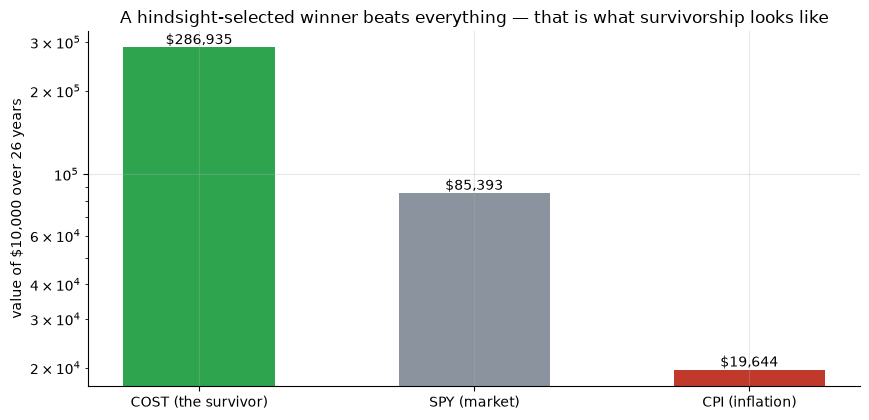

COST (the survivor)    $   286,935
SPY (market)           $    85,393
CPI (inflation)        $    19,644


In [7]:
start=10_000.0
ends={'COST (the survivor)':R['cost_10k'], 'SPY (market)':R['spy_10k'], 'CPI (inflation)':R['cpi_10k']}
fig, ax = plt.subplots(figsize=(8.8,4.3))
ax.bar(list(ends), list(ends.values()), .55, color=[GREEN, GREY, RED])
for i,v in enumerate(ends.values()): ax.annotate(f'${v:,.0f}',(i,v),ha='center',va='bottom')
ax.set_ylabel(f'value of $10,000 over {R["years"]:.0f} years'); ax.set_yscale('log')
ax.set_title('A hindsight-selected winner beats everything — that is what survivorship looks like')
plt.tight_layout(); plt.show()
for k,v in ends.items(): print(f'{k:22s} ${v:>10,.0f}')

> 💡 In plain words: COST's terminal wealth dwarfs SPY and CPI — but that gap is the **signature of survivorship**, not of an inflation hedge. We conditioned on the winner. The inflation-surprise beta (the part that would generalise to a *rule* you could run ex-ante) is zero. There is no size, venue, or overlay that turns a frozen loss-leader's fame into a tradable inflation edge.

## 7 · Going further

- **Try core CPI / PCE.** We use the real `CPIAUCSL` (BLS `CUSR0000SA0`); swap in core CPI or PCE and re-run — a beta that's ~zero and inside its placebo won't wake up.
- **A cross-section of 'pricing-power' names.** WMT, MCD, PG, KO: estimate each inflation-surprise beta vs XLP — is *any* consumer champion a real hedge, or is the halo always a story?
- **Kill the survivorship.** Form a 2000-vintage basket without hindsight and re-race — the COST-vs-SPY gap is a selection artifact ([docs/references.md](../docs/references.md)).

*The reproducible core is offline and deterministic; CPI is the **real** FRED/BLS `CPIAUCSL` series (fetched from BLS and cached) and COST/SPY/XLP are real month-end total-return tape. Methods: [`docs/references.md`](../docs/references.md); frozen numbers (fp `cbd3b6799d57`): [`docs/results.md`](../docs/results.md).*